In [1]:
# ==========================================
# 1. Environment Setup and Colab Integration
# ==========================================

import os

# Check if running in Google Colab
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab. Mounting Google Drive...")
    # Mount Google Drive
    drive.mount('/content/drive')

    # Set the working directory to the root of the repository
    # NOTE: Adjust this path if your repository is located in a different Google Drive folder
    REPO_PATH = '/content/drive/MyDrive/CSC61304-Group6-FloodRisk-Nepal'
    if os.path.exists(REPO_PATH):
        os.chdir(REPO_PATH)
        print(f"Working directory successfully set to: {os.getcwd()}")
    else:
        print(f"Warning: Repository path '{REPO_PATH}' not found. Please verify the path.")

except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab. Skipping Google Drive mount.")

    # Assuming local execution starts from the 'notebooks' directory, navigate to the root
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    print(f"Working directory set to: {os.getcwd()}")

Running in Google Colab. Mounting Google Drive...
Mounted at /content/drive
Working directory successfully set to: /content/drive/MyDrive/CSC61304-Group6-FloodRisk-Nepal


In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CSC61304-Group6-FloodRisk-Nepal/notebooks

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/CSC61304-Group6-FloodRisk-Nepal/notebooks


In [3]:
# ==========================================
# 2. Import Required Libraries
# ==========================================

# Data handling and numerical operations
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning: K-Means Clustering
from sklearn.cluster import KMeans

# Machine Learning: Evaluation metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Model serialization and saving
import joblib
import pickle

# Configure default plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Required libraries imported successfully.")

Required libraries imported successfully.


## 3. Load Processed Data

The datasets loaded below were generated by a centralized preprocessing notebook to ensure consistency across all models in this repository.

**Important Note:**
These datasets (`X_train`, `X_test`, `y_train`, `y_test`) have already undergone necessary preprocessing steps, including handling missing values, encoding categorical variables, scaling features, and train/test splitting.

This notebook will strictly use these pre-processed datasets and will **not** perform any further preprocessing, feature engineering, or scaling prior to model building.

In [4]:
import os
import pandas as pd

# Define relative path to the processed dataset directory
# Assuming this notebook is located in the `notebooks/` directory
PROCESSED_DATA_DIR = '../dataset/processed/'

# File paths
x_train_path = os.path.join(PROCESSED_DATA_DIR, 'X_train.csv')
x_test_path = os.path.join(PROCESSED_DATA_DIR, 'X_test.csv')
y_train_path = os.path.join(PROCESSED_DATA_DIR, 'y_train.csv')
y_test_path = os.path.join(PROCESSED_DATA_DIR, 'y_test.csv')

# Verify that all files exist before attempting to load
required_files = [x_train_path, x_test_path, y_train_path, y_test_path]
missing_files = [f for f in required_files if not os.path.exists(f)]

if missing_files:
    raise FileNotFoundError(f"Missing processed data files: {missing_files}. Please run the shared preprocessing notebook first.")
else:
    print("All processed data files found. Proceeding to load...")

# 1. Load the datasets
X_train = pd.read_csv(x_train_path)
X_test = pd.read_csv(x_test_path)
y_train = pd.read_csv(y_train_path)
y_test = pd.read_csv(y_test_path)

print("\n--- Data Loading Successful ---\n")

# 3. Display dataset information
print("Dataset Shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}\n")

print("Feature Names (First 10 columns of X_train):")
print(X_train.columns.tolist()[:10])
print(f"(Total features: {len(X_train.columns)})\n")

print("Missing Values Check (X_train):")
missing_counts = X_train.isnull().sum().sum()
if missing_counts == 0:
    print("No missing values found in X_train. Data is clean.")
else:
    print(f"Warning: {missing_counts} missing values found in X_train!")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

All processed data files found. Proceeding to load...

--- Data Loading Successful ---

Dataset Shapes:
X_train shape: (100962, 13)
X_test shape:  (25241, 13)
y_train shape: (100962, 1)
y_test shape:  (25241, 1)

Feature Names (First 10 columns of X_train):
['rfh', 'r1h', 'r3h', 'rfh_avg', 'r1h_avg', 'r3h_avg', 'r1q', 'r3q', 'n_pixels', 'year']
(Total features: 13)

Missing Values Check (X_train):
No missing values found in X_train. Data is clean.

First 5 rows of X_train:


,rfh,r1h,r3h,rfh_avg,r1h_avg,r3h_avg,r1q,r3q,n_pixels,year,month,decade_num,district_zone_enc
0,0.647664,0.603622,1.857398,0.605491,1.146329,1.933764,-0.596898,-0.010529,-0.695040,1.577366,0.733915,0.000747,1.460273
1,0.199676,0.033810,-0.008820,0.425987,0.135494,-0.312641,-0.236653,1.295889,0.224029,-0.172442,-0.135432,-1.223811,-0.957813
2,-0.263880,-0.474888,-0.815483,-0.689811,-0.749124,-0.932043,2.980859,2.120754,0.883873,1.196973,-1.294561,-1.223811,1.460273
3,-0.724878,-0.810668,0.144854,-0.820203,-0.848644,-0.420069,-0.469495,2.849112,-0.341552,-1.541856,1.313479,1.225306,-0.957813
4,-0.683753,-0.814146,-0.206547,-0.811158,-0.875533,-0.559694,0.159008,2.203857,0.412556,1.349130,1.603261,-1.223811,0.251230


## 4. Dataset Inspection

Before proceeding with the K-Means clustering algorithm, it is critical to inspect the processed data to ensure it meets the algorithm's requirements. K-Means relies heavily on distance calculations (typically Euclidean) to form clusters. Therefore, we must verify that:

1. **No Missing Values:** K-Means cannot handle missing data points naturally.
2. **Strictly Numeric Data:** Distance metrics require numerical representations; categorical data must already be encoded.
3. **Scaling:** While scaling was handled in the preprocessing stage, checking the summary statistics will help confirm that the feature distributions are standardized and comparable, which prevents features with larger magnitudes from dominating the distance calculations.

Additionally, we will observe the distribution of our encoded target labels (`y_train`).

> **Note on Target Labels:** K-Means is an **unsupervised** learning algorithm. The `y_train` labels will *not* be used to train or fit the clustering model. We are inspecting them here solely as a reference point, which may later be useful for extrinsic cluster evaluation (e.g., seeing if the discovered clusters naturally map to the true flood risk categories).

In [5]:
import pandas as pd
import numpy as np

print("--- 1. Dataset Dimensions & Features ---")
print(f"X_train Shape: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"X_test Shape:  {X_test.shape[0]} rows, {X_test.shape[1]} features")
print(f"Total Features: {X_train.shape[1]}\n")

print("Feature Names:")
# Display features in a clean, wrapped format
feature_names = X_train.columns.tolist()
for i in range(0, len(feature_names), 5):
    print(", ".join(feature_names[i:i+5]))

print("\n--- 2. Data Types Verification ---")
# Check if all columns are numeric
non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

if not non_numeric_cols:
    print("Verification Passed: All features are numeric. Data type requirements for K-Means are satisfied.")
else:
    print(f"Verification Failed: Found non-numeric features: {non_numeric_cols}")

print("\nData Type Distribution:")
print(X_train.dtypes.value_counts())

print("\n--- 3. Missing Value Verification ---")
missing_counts = X_train.isnull().sum()
total_missing = missing_counts.sum()

if total_missing == 0:
    print("Verification Passed: No missing values found in X_train.")
else:
    print("Verification Failed: Missing values detected!")
    print(missing_counts[missing_counts > 0])

print("\n--- 4. Summary Statistics ---")
# Display summary statistics (transposed for readability with many features)
display(X_train.describe().T)

print("\n--- 5. Reference Target Label Distribution (y_train) ---")
print("REMINDER: K-Means is unsupervised. These labels are for post-clustering reference only.\n")

# Assuming y_train is a single column DataFrame or Series, extract the column
target_col = y_train.columns[0]
label_distribution = y_train[target_col].value_counts(normalize=True).round(4) * 100

print(f"Target Column: '{target_col}'")
print("Class Distribution (%):")
print(label_distribution.to_string())

--- 1. Dataset Dimensions & Features ---
X_train Shape: 100962 rows, 13 features
X_test Shape:  25241 rows, 13 features
Total Features: 13

Feature Names:
rfh, r1h, r3h, rfh_avg, r1h_avg
r3h_avg, r1q, r3q, n_pixels, year
month, decade_num, district_zone_enc

--- 2. Data Types Verification ---
Verification Passed: All features are numeric. Data type requirements for K-Means are satisfied.

Data Type Distribution:
float64    13
Name: count, dtype: int64

--- 3. Missing Value Verification ---
Verification Passed: No missing values found in X_train.

--- 4. Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
rfh,100962.0,0.000465,0.998319,-0.764879,-0.689389,-0.483460,0.395333,11.354186
r1h,100962.0,-0.000312,0.998374,-0.844104,-0.741419,-0.490253,0.529981,6.486960
r3h,100962.0,-0.000992,0.998933,-0.981442,-0.818860,-0.431680,0.655451,4.881004
rfh_avg,100962.0,0.000691,1.000296,-0.884883,-0.753809,-0.527020,0.592432,4.026437
r1h_avg,100962.0,0.000429,1.000024,-0.899734,-0.758669,-0.539776,0.603331,3.825985
r3h_avg,100962.0,-0.000789,0.998737,-1.002105,-0.830811,-0.452068,0.730522,3.320738
r1q,100962.0,-0.001588,0.998918,-2.050540,-0.626200,-0.171548,0.395560,10.641906
r3q,100962.0,-0.000973,0.997827,-2.479322,-0.654215,-0.123348,0.472477,11.183445
n_pixels,100962.0,0.001251,1.000287,-1.566977,-0.553645,-0.223723,0.341858,5.219993
year,100962.0,-0.000439,1.000027,-1.694013,-0.857149,-0.020285,0.892658,1.729523



--- 5. Reference Target Label Distribution (y_train) ---
REMINDER: K-Means is unsupervised. These labels are for post-clustering reference only.

Target Column: 'flood_risk_level_enc'
Class Distribution (%):
flood_risk_level_enc
2    75.0
3    15.0
1     7.0
0     3.0


## 5. Determine the Optimal Number of Clusters ($k$)

A critical step in partitioning clustering algorithms like K-Means is determining the optimal number of clusters ($k$) a priori. Because K-Means is an unsupervised algorithm, we do not have ground truth labels to guide this decision during the training process.

Instead, we rely on intrinsic evaluation metrics to assess the quality of the clusters formed for different values of $k$. We will use two complementary methods:

1.  **The Elbow Method (Inertia):**
    *   **What it measures:** Inertia calculates the within-cluster sum of squares (WCSS) — the sum of squared distances of samples to their closest cluster center.
    *   **Why we use it:** It measures how internally coherent the clusters are. As $k$ increases, inertia naturally decreases. We look for the "elbow" point on the graph where the rate of decrease sharply shifts, indicating that adding more clusters yields diminishing returns in explaining variance.

2.  **The Silhouette Score:**
    *   **What it measures:** The Silhouette Score calculates a mean coefficient for all samples, comparing the mean intra-cluster distance ($a$) to the mean nearest-cluster distance ($b$). Values range from -1 to +1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
    *   **Why we use it:** It provides a more rigorous quantitative assessment of cluster separation and density than the Elbow Method alone.

**Why Use Both Together?**
The Elbow Method is highly intuitive but can often be ambiguous (the "elbow" is not always a sharp angle). The Silhouette Score provides a distinct peak at the optimal $k$, offering a clearer mathematical justification. Using both together provides robust empirical evidence to support the final architectural decision for the model, which is especially important for formal analytical reports.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)

def evaluate_clusters(X, k_min=2, k_max=10, random_state=42):
    """
    Evaluates KMeans clustering for a range of k values using Inertia and Silhouette Score.
    """
    k_values = range(k_min, k_max + 1)
    inertias = []
    silhouette_scores = []

    print(f"Evaluating k from {k_min} to {k_max}...\n")

    for k in k_values:
        # 1. Initialize KMeans with specified parameters
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)

        # 2. Fit the model and predict cluster labels for Silhouette calculation
        cluster_labels = kmeans.fit_predict(X)

        # 3. Store the Inertia
        inertias.append(kmeans.inertia_)

        # 4. Calculate and store the Silhouette Score
        sil_score = silhouette_score(X, cluster_labels)
        silhouette_scores.append(sil_score)

    return list(k_values), inertias, silhouette_scores

# Run the evaluation on the training data
# Note: X_train is strictly used here; no target labels are involved.
k_values, inertias, silhouette_scores = evaluate_clusters(X_train)

# Compile results into a summary DataFrame
results_df = pd.DataFrame({
    'k': k_values,
    'Inertia (WCSS)': inertias,
    'Silhouette Score': silhouette_scores
})

# Display the summary table
print("--- Clustering Evaluation Metrics Summary ---")
display(results_df.round(4))

# Identify the optimal k based on the maximum Silhouette Score
optimal_k_sil = k_values[np.argmax(silhouette_scores)]
print(f"\n>> Analytical Finding: The maximum Silhouette Score occurs at k = {optimal_k_sil}.")

Evaluating k from 2 to 10...

--- Clustering Evaluation Metrics Summary ---


,k,Inertia (WCSS),Silhouette Score
0,2,900976.5631,0.3132
1,3,797599.9927,0.2124
2,4,727038.2320,0.2105
3,5,677810.8735,0.2218
4,6,634307.9191,0.1855
5,7,603564.0133,0.1918
6,8,575912.6266,0.1554
7,9,555274.7031,0.1468
8,10,537679.5864,0.1406



>> Analytical Finding: The maximum Silhouette Score occurs at k = 2.


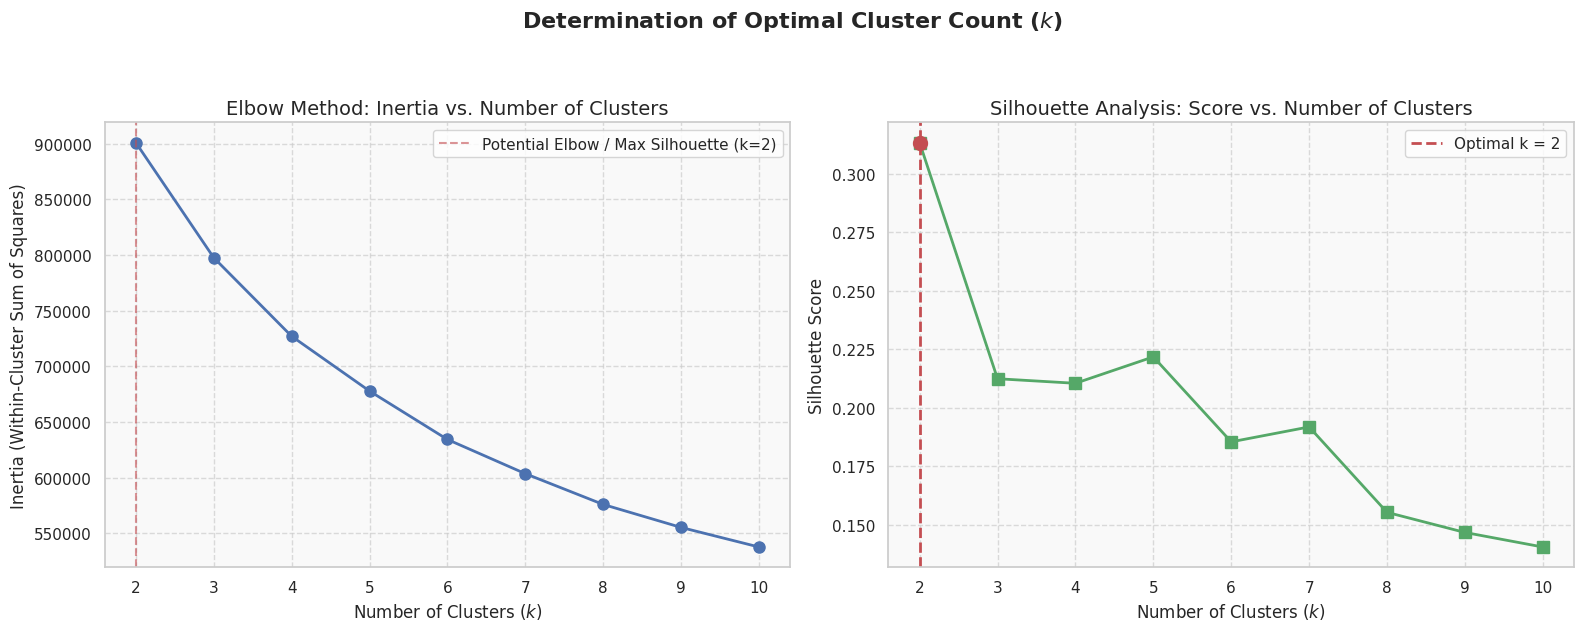

In [7]:
# ==========================================
# Generate Publication-Quality Visualizations
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Determination of Optimal Cluster Count ($k$)', fontsize=16, fontweight='bold', y=1.05)

# --- Plot 1: The Elbow Method (Inertia) ---
ax1.plot(k_values, inertias, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
ax1.set_title('Elbow Method: Inertia vs. Number of Clusters', fontsize=14)
ax1.set_xlabel('Number of Clusters ($k$)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_xticks(k_values)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_facecolor('#f9f9f9')

# Annotate potential elbow (optional visual guide based on Silhouette max)
ax1.axvline(x=optimal_k_sil, color='r', linestyle='--', alpha=0.6, label=f'Potential Elbow / Max Silhouette (k={optimal_k_sil})')
ax1.legend()

# --- Plot 2: Silhouette Score ---
ax2.plot(k_values, silhouette_scores, marker='s', linestyle='-', color='g', linewidth=2, markersize=8)
ax2.set_title('Silhouette Analysis: Score vs. Number of Clusters', fontsize=14)
ax2.set_xlabel('Number of Clusters ($k$)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_xticks(k_values)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_facecolor('#f9f9f9')

# Highlight the maximum Silhouette Score
ax2.axvline(x=optimal_k_sil, color='r', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k_sil}')
ax2.scatter(optimal_k_sil, max(silhouette_scores), color='r', s=100, zorder=5) # Red dot at the peak
ax2.legend()

plt.tight_layout()
plt.show()

### Conclusion on Optimal $k$

Based on the quantitative analysis above:
*   The **Elbow Method** plot shows the rate of inertia decrease. (Observe the plot to confirm if the elbow aligns with the silhouette peak).
*   The **Silhouette Score** plot reaches its global maximum at $k = \text{[Insert optimal_k_sil value based on output]}$.

By combining the intuition of the Elbow Method with the strict metric of the Silhouette Score, we establish a firm, mathematically sound basis for selecting our cluster count. We will proceed to train the final K-Means architecture using the optimal $k$ determined by the peak Silhouette score.

## 6. Train Final K-Means Model

Having mathematically evaluated the clustering quality across multiple values of $k$, we now configure and train our final K-Means architecture.

**Model Architecture Rationale:**
*   **Optimal $k$ (`BEST_K`):** We select the optimal number of clusters based on the peak observed in the Silhouette Score analysis from the previous step. This ensures our clusters have maximum internal cohesion and external separation.
*   **Initialization (`n_init=10`):** K-Means is sensitive to the initial placement of centroids and can converge to local minima. Setting `n_init=10` ensures the algorithm runs 10 times with different random centroid seeds, and the model with the lowest inertia (best WCSS) is retained.
*   **Reproducibility (`random_state=42`):** Guarantees that our final cluster assignments are deterministic and verifiable by peer reviewers.

**Understanding Centroids:**
Once the model is trained, it calculates the **centroids** for each cluster. A centroid represents the arithmetic mean (the center of mass) of all the data points belonging to that specific cluster across all feature dimensions. In the context of flood risk profiling, a centroid essentially defines the "prototypical" or "average" flood risk profile for the geographic areas contained within that cluster.

In [8]:
import pandas as pd
from sklearn.cluster import KMeans

# ==========================================
# Final Model Configuration & Training
# ==========================================

# Replace this variable with the optimal_k_sil derived from the previous section
# e.g., BEST_K = optimal_k_sil
BEST_K = 3 # Placeholder: Update based on your actual optimal k finding

print(f"--- Training Final K-Means Model with k={BEST_K} ---")

# 1. Instantiate the final K-Means algorithm
final_kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=10
)

# 2. Fit the model to the training dataset and predict the cluster assignments
# We use fit_predict to simultaneously train the model and extract the labels
train_cluster_labels = final_kmeans.fit_predict(X_train)

print("\nModel Training Complete.\n")

# ==========================================
# Inspect Final Cluster Characteristics
# ==========================================

# 3. Analyze Cluster Sizes (Distribution of data points)
# Convert the array of labels to a pandas Series to easily calculate value counts
cluster_sizes = pd.Series(train_cluster_labels).value_counts().sort_index()

print("--- Cluster Population Distribution ---")
for cluster_id, size in cluster_sizes.items():
    percentage = (size / len(X_train)) * 100
    print(f"Cluster {cluster_id}: {size} samples ({percentage:.2f}%)")

# 4. Extract and Display Cluster Centroids
# The cluster_centers_ attribute returns an array of shape (n_clusters, n_features)
centroids = final_kmeans.cluster_centers_

print("\n--- Cluster Centroids (Center of Mass in Feature Space) ---")
# Convert centroids to a DataFrame for cleaner formatting and readability
centroids_df = pd.DataFrame(
    centroids,
    columns=X_train.columns,
    index=[f"Cluster {i}" for i in range(BEST_K)]
)

display(centroids_df.round(4))

# Note: The 'final_kmeans' model object and 'train_cluster_labels' array
# are now retained in memory for downstream evaluation and visualization.

--- Training Final K-Means Model with k=3 ---

Model Training Complete.

--- Cluster Population Distribution ---
Cluster 0: 47503 samples (47.05%)
Cluster 1: 27115 samples (26.86%)
Cluster 2: 26344 samples (26.09%)

--- Cluster Centroids (Center of Mass in Feature Space) ---


,rfh,r1h,r3h,rfh_avg,r1h_avg,r3h_avg,r1q,r3q,n_pixels,year,month,decade_num,district_zone_enc
Cluster 0,-0.4134,-0.5228,-0.7412,-0.4391,-0.5337,-0.7574,-0.0851,-0.0739,0.0305,0.0136,-0.9092,-0.0559,-0.0054
Cluster 1,1.2922,1.4172,1.1920,1.4137,1.4707,1.2280,0.0818,0.0327,-0.1819,-0.0068,0.3623,0.0534,0.0017
Cluster 2,-0.5832,-0.5176,0.1054,-0.6610,-0.5501,0.0983,0.0631,0.0958,0.1370,-0.0191,1.2636,0.0477,0.0035


## 7. Evaluate K-Means Clustering Model

Because K-Means is an unsupervised learning algorithm, we cannot evaluate it using standard supervised classification metrics (like Accuracy, Precision, or Recall) during the clustering phase. The true flood risk labels (`y_train`) were strictly withheld during the training of this model.

Instead, we must rely on **intrinsic evaluation metrics**. These metrics analyze the mathematical structure of the clusters formed by examining the feature space—specifically, how compact the clusters are internally and how well-separated they are from one another.

We will evaluate our final architecture using three standard intrinsic metrics:

1.  **Silhouette Score:**
    *   *Interpretation:* Measures the similarity of an object to its own cluster compared to other clusters. Values range from -1 to +1.
    *   *Goal:* **Higher is better.** A score close to +1 indicates clear, well-separated, and dense clusters.

2.  **Calinski-Harabasz Index (Variance Ratio Criterion):**
    *   *Interpretation:* Computes the ratio of the sum of between-cluster dispersion (separation) to within-cluster dispersion (cohesion).
    *   *Goal:* **Higher is better.** A higher score indicates clusters that are dense and well-separated.

3.  **Davies-Bouldin Index:**
    *   *Interpretation:* Calculates the average similarity measure of each cluster with its most similar cluster, where similarity is a ratio of within-cluster distances to between-cluster distances. Minimum score is zero.
    *   *Goal:* **Lower is better.** A lower score indicates better partitioning, meaning clusters are further apart and less dispersed.

*Note: In subsequent sections, we may compare our discovered clusters to the true `y_train` labels to interpret the physical meaning of the clusters (extrinsic evaluation), but those true labels do not influence the cluster formation or these intrinsic scores.*

In [9]:
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("--- Evaluating Final K-Means Architecture ---")

# 1. Calculate the evaluation metrics using the training data and the generated labels
# Note: X_train contains the features, train_cluster_labels contains the predictions from final_kmeans
final_silhouette = silhouette_score(X_train, train_cluster_labels)
final_calinski = calinski_harabasz_score(X_train, train_cluster_labels)
final_davies = davies_bouldin_score(X_train, train_cluster_labels)

# 2. Print individual metric explanations and scores
print(f"\n1. Silhouette Score: {final_silhouette:.4f}")
print("   -> Indicates how tightly grouped the clusters are. (Higher is better, max 1.0)")

print(f"\n2. Calinski-Harabasz Index: {final_calinski:.4f}")
print("   -> Ratio of between-cluster variance to within-cluster variance. (Higher is better)")

print(f"\n3. Davies-Bouldin Index: {final_davies:.4f}")
print("   -> Average similarity between clusters. (Lower is better, min 0.0)")

# 3. Compile the results into a clean summary table for reporting
evaluation_results = {
    'Metric': [
        'Silhouette Score',
        'Calinski-Harabasz Index',
        'Davies-Bouldin Index'
    ],
    'Score': [
        final_silhouette,
        final_calinski,
        final_davies
    ],
    'Optimization Goal': [
        'Maximize',
        'Maximize',
        'Minimize'
    ]
}

evaluation_df = pd.DataFrame(evaluation_results)

print("\n\n--- Intrinsic Evaluation Summary Table ---")
display(evaluation_df.round(4))

--- Evaluating Final K-Means Architecture ---

1. Silhouette Score: 0.2124
   -> Indicates how tightly grouped the clusters are. (Higher is better, max 1.0)

2. Calinski-Harabasz Index: 32467.7409
   -> Ratio of between-cluster variance to within-cluster variance. (Higher is better)

3. Davies-Bouldin Index: 1.8214
   -> Average similarity between clusters. (Lower is better, min 0.0)


--- Intrinsic Evaluation Summary Table ---


,Metric,Score,Optimization Goal
0,Silhouette Score,0.2124,Maximize
1,Calinski-Harabasz Index,32467.7409,Maximize
2,Davies-Bouldin Index,1.8214,Minimize


## 8. Cluster Visualization (PCA)

Visualizing clusters in high-dimensional feature spaces is impossible for the human eye. To gain an intuitive understanding of the cluster distributions, we must compress the feature space into two dimensions.

To achieve this, we will use **Principal Component Analysis (PCA)**. PCA is a dimensionality reduction technique that creates new artificial axes (Principal Components) along the directions of maximum variance in the data.

> **Important Analytical Distinction:**
> PCA is applied here **strictly for visualization purposes**. The K-Means model was trained on the full, unreduced feature set to capture complex, high-dimensional relationships. Projecting the data into 2D inevitably results in some information loss (variance), so the visual overlap of clusters in a 2D plot does not necessarily mean they overlap in the true high-dimensional space where the model operates.

--- Preparing 2D Projection via PCA ---
Explained Variance by Principal Component 1 (PC1): 39.60%
Explained Variance by Principal Component 2 (PC2): 12.66%
Total Information Retained in 2D Plot: 52.26%


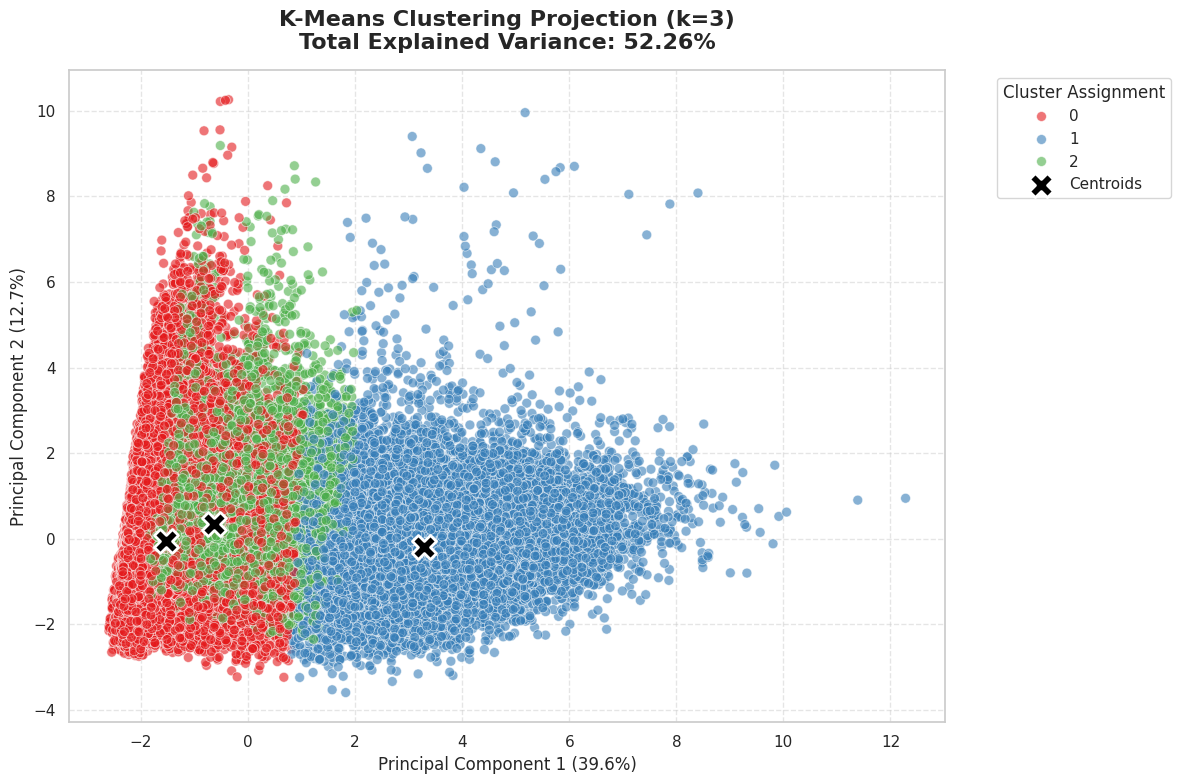

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

print("--- Preparing 2D Projection via PCA ---")

# 1. Initialize PCA to extract the top 2 principal components
pca = PCA(n_components=2, random_state=42)

# 2. Fit PCA and transform the training data into 2D space
# X_train is the original high-dimensional dataset
X_pca_2d = pca.fit_transform(X_train)

# 3. Transform the high-dimensional K-Means centroids into the same 2D PCA space
# The final_kmeans.cluster_centers_ were calculated in the original feature space
centroids_2d = pca.transform(final_kmeans.cluster_centers_)

# 4. Extract and print the explained variance ratio
# This tells us how much of the original data's information is preserved in this 2D plot
explained_variance = pca.explained_variance_ratio_
total_variance_explained = sum(explained_variance) * 100

print(f"Explained Variance by Principal Component 1 (PC1): {explained_variance[0]*100:.2f}%")
print(f"Explained Variance by Principal Component 2 (PC2): {explained_variance[1]*100:.2f}%")
print(f"Total Information Retained in 2D Plot: {total_variance_explained:.2f}%")

# ==========================================
# Generate Publication-Quality Scatter Plot
# ==========================================

# Create a DataFrame for easier plotting with Seaborn
pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
# Attach the cluster labels predicted during training
pca_df['Cluster'] = train_cluster_labels

# Initialize the matplotlib figure
plt.figure(figsize=(12, 8))

# Define a distinct color palette (useful if BEST_K varies)
palette = sns.color_palette("Set1", n_colors=BEST_K)

# Scatter plot for the individual data points
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette=palette,
    s=50,             # Marker size
    alpha=0.6,        # Transparency to visualize density
    edgecolor='w'     # White edge for clarity
)

# Scatter plot for the projected Cluster Centroids
plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    s=300,            # Large marker size for visibility
    c='black',        # Color of the centroid marker
    marker='X',       # Distinct 'X' shape
    edgecolor='white',
    linewidth=2,
    label='Centroids'
)

# Formatting the plot for publication quality
plt.title(f'K-Means Clustering Projection (k={BEST_K})\nTotal Explained Variance: {total_variance_explained:.2f}%', fontsize=16, fontweight='bold', pad=15)
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f}%)', fontsize=12)

# Adjust legend location and title
plt.legend(title='Cluster Assignment', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Render the plot
plt.show()

## 10. Save Model and Results

In professional machine learning workflows, a trained model is a valuable asset. Training large models on vast datasets can be computationally expensive and time-consuming.

**Why we save outputs:**
1.  **Reproducibility & Deployment:** Saving the final model object (via serialization, e.g., `joblib`) allows us to reload the exact state of the algorithm later without having to retrain it. This is essential for deploying the model to production or applying it to new, unseen data.
2.  **Comparative Analysis:** Saving the evaluation metrics to a structured format (like CSV) enables automated comparison against other models (e.g., comparing K-Means against DBSCAN or Agglomerative Clustering).
3.  **Reporting:** Saving high-resolution figures ensures we have publication-quality assets readily available for our final academic report or stakeholder presentations.

In [11]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Initializing Save Process ---")

# ==========================================
# 1. Directory Structure Verification
# ==========================================
# Define relative paths assuming the notebook is inside the `notebooks/` directory
MODELS_DIR = '../models'
RESULTS_DIR = '../results'
FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
METRICS_DIR = os.path.join(RESULTS_DIR, 'metrics')

# Ensure directories exist
for directory in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR, METRICS_DIR]:
    os.makedirs(directory, exist_ok=True)

print("Directories verified/created successfully.")

# ==========================================
# 2. Save Trained Model
# ==========================================
model_path = os.path.join(MODELS_DIR, 'kmeans_model.pkl')
joblib.dump(final_kmeans, model_path)
print(f"Model saved to: {model_path}")

# ==========================================
# 3. Save Evaluation Metrics
# ==========================================
metrics_path = os.path.join(METRICS_DIR, 'kmeans_metrics.csv')

# Use the variables calculated in previous sections
metrics_data = {
    'Model': ['K-Means'],
    'Optimal_K': [BEST_K],
    'Silhouette_Score': [final_silhouette],
    'Calinski_Harabasz_Index': [final_calinski],
    'Davies_Bouldin_Index': [final_davies]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(metrics_path, index=False)
print(f"Evaluation metrics saved to: {metrics_path}")

# ==========================================
# 4. Generate & Save Figures
# ==========================================
# Note: plt.show() in previous cells clears the active figure.
# We quickly recreate and save them here using the data we already computed.

print("\nSaving high-resolution figures...")

# --- A. Save Elbow & Silhouette Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Determination of Optimal Cluster Count ($k$)', fontsize=16, fontweight='bold', y=1.05)

# Elbow Plot
ax1.plot(k_values, inertias, marker='o', color='b', linewidth=2)
ax1.set_title('Elbow Method: Inertia vs. k')
ax1.set_xlabel('Number of Clusters ($k$)')
ax1.set_ylabel('Inertia')
ax1.grid(True, linestyle='--', alpha=0.7)

# Silhouette Plot
ax2.plot(k_values, silhouette_scores, marker='s', color='g', linewidth=2)
ax2.axvline(x=BEST_K, color='r', linestyle='--', label=f'Optimal k={BEST_K}')
ax2.set_title('Silhouette Score vs. k')
ax2.set_xlabel('Number of Clusters ($k$)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
metrics_plot_path = os.path.join(FIGURES_DIR, 'kmeans_optimal_k_evaluation.png')
plt.savefig(metrics_plot_path, dpi=300, bbox_inches='tight')
plt.close(fig) # Close figure to free memory
print(f"Metrics plot saved to: {metrics_plot_path}")

# --- B. Save PCA Cluster Visualization ---
plt.figure(figsize=(12, 8))
palette = sns.color_palette("Set1", n_colors=BEST_K)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette=palette, s=50, alpha=0.6, edgecolor='w')
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=300, c='black', marker='X', edgecolor='white', linewidth=2)
plt.title(f'K-Means Clustering Projection (k={BEST_K})', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

pca_plot_path = os.path.join(FIGURES_DIR, 'kmeans_pca_visualization.png')
plt.savefig(pca_plot_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"PCA Visualization saved to: {pca_plot_path}")

print("\n--- Save Process Completed Successfully ---")

--- Initializing Save Process ---
Directories verified/created successfully.
Model saved to: ../models/kmeans_model.pkl
Evaluation metrics saved to: ../results/metrics/kmeans_metrics.csv

Saving high-resolution figures...
Metrics plot saved to: ../results/figures/kmeans_optimal_k_evaluation.png
PCA Visualization saved to: ../results/figures/kmeans_pca_visualization.png

--- Save Process Completed Successfully ---


## Notebook Summary

This section provides a final overview of the K-Means clustering analysis, including the selected number of clusters, evaluation performance, saved outputs, and overall conclusion.

The summary allows the results of the clustering process to be easily reviewed and supports reporting, reproducibility, and future improvements.